# 04 - COVID-19 Bivariate Analysis

This notebook analyzes relationships between pairs of COVID-19 variables.

## Import Libraries

In [70]:
import os
from pathlib import Path

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the data loader module
from src.data_loader import change_dtypes
from src.visualization import set_style

# Set visualization style
set_style()

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [72]:
countries = pd.read_csv("data/processed/countries.csv", parse_dates=["date"])
countries = change_dtypes(countries)
countries.head()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.436315,10.9,51.938343,0.39


From the Univariate Analysis, we decided to inspect these bivariate relationships:

* **Handwashing facilities vs. Deaths**: analyze if countries with less handwashing facilities had more deaths.
* **Hospital beds vs. Deaths**: analyze if countries with more hospital beds (proxy for sanitary capacity) resulted in less deaths.
* **Life Expectancy / Median Age vs. Deaths**: analyze if countries with less life expectancy had more deaths, as the people is less prepared in those countries. (Warning! It is not that people in countries with better life expectancy die because having good sanitary, is because they have got more "risky population" and better counting systems).

In [73]:
# Aggregate the data

cols_bivariate = ["date", "country", "continent", "total_deaths_per_million", "handwashing_facilities", "hospital_beds_per_thousand", "life_expectancy", "median_age", "gdp_per_capita"]

bivariate = countries[countries["date"] == countries["date"].max()][cols_bivariate].reset_index(drop=True).dropna()
bivariate.head()

,date,country,continent,total_deaths_per_million,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,median_age,gdp_per_capita
0,2023-04-30,Afghanistan,Asia,194.48557,51.938343,0.39,65.616997,16.752001,1516.273315
1,2023-04-30,Albania,Europe,1274.57290,97.261055,2.89,78.768799,35.943001,15492.067383
2,2023-04-30,Algeria,Africa,151.30595,84.927719,1.90,76.128899,27.983000,11198.233398
3,2023-04-30,American Samoa,Oceania,702.98770,71.936287,2.00,72.752098,27.927000,5579.981445
4,2023-04-30,Andorra,Europe,1994.43070,97.261055,4.57,84.016403,42.832001,40223.011719


Now, we want to make a binning of the sanitary and socioeconomic variables in order to analyze the difference between countries.

In [74]:
import pandas as pd

cols_to_bin = ["handwashing_facilities", "hospital_beds_per_thousand", "life_expectancy", "median_age"]

labels = ['Low', 'Average', 'High']

for col in cols_to_bin:
    # duplicates='drop' in case there are same values
    bivariate[f'{col}_bin'] = pd.qcut(bivariate[col], q=3, labels=labels, duplicates='drop')

print("Here is an example\n")
print(bivariate[[cols_to_bin[0], f'{cols_to_bin[0]}_bin']].head())

Here is an example

   handwashing_facilities handwashing_facilities_bin
0               51.938343                        Low
1               97.261055                       High
2               84.927719                    Average
3               71.936287                        Low
4               97.261055                       High


### Handwashing Facilities vs deaths

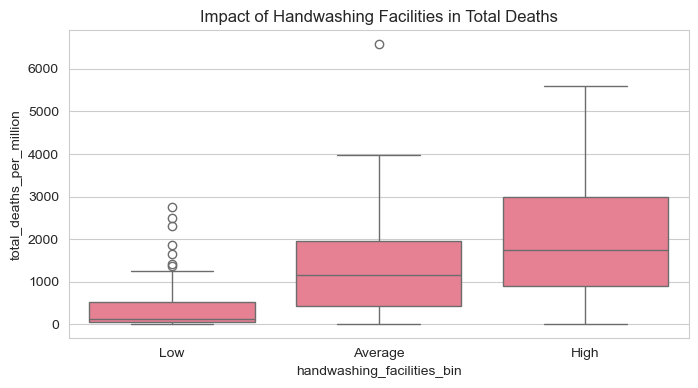

In [75]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='handwashing_facilities_bin', y='total_deaths_per_million', data=bivariate)
plt.title('Impact of Handwashing Facilities in Total Deaths')
plt.show()

As we can see, the higher the handwashing facilities a country has, the most deaths per million. This may be biased because another variable such as median age or life expectancy can be distorting the results. Richer countries with more handwashing facilities tend to have older people, and COVID could affect this people more.

In [76]:
import pingouin as pg
data_ancova = bivariate.dropna(subset=['total_deaths_per_million', 'handwashing_facilities_bin', 'median_age'])

# dv: dependent variable (deaths)
# between: grouped factor (handwashing binned)
# covar: the variable we want to control (age)
ancova_res = pg.ancova(data=data_ancova, dv='total_deaths_per_million', 
                       between='handwashing_facilities_bin', covar='median_age')

print(ancova_res)

                       Source            SS   DF          F         p-unc  \
0  handwashing_facilities_bin  1.443386e+07    2   6.688900  1.502217e-03   
1                  median_age  4.339352e+07    1  40.218604  1.197845e-09   
2                    Residual  2.470776e+08  229        NaN           NaN   

        np2  
0  0.055194  
1  0.149390  
2       NaN  


As we can see, we guessed right! At first, we saw a positive linear correlation between these 2 variables.

However, we thought that this could be due to the effect of age. Countries with better sanitary infraestructure (handwashing facilities) tend to be nations more developed and with older people, which are more vulnerable to COVID.

We performed a ANCOVA test, controlling only for age and we saw that the coefficient dropped down drastically.

Conclusion: this confirms that the handwashing facilities factor is not a risky one, as its initial correlation was biased by age. Moreover, it probably exists a report bias, where the countries with more resources register with more precision the death causes.

### Hospital beds vs deaths

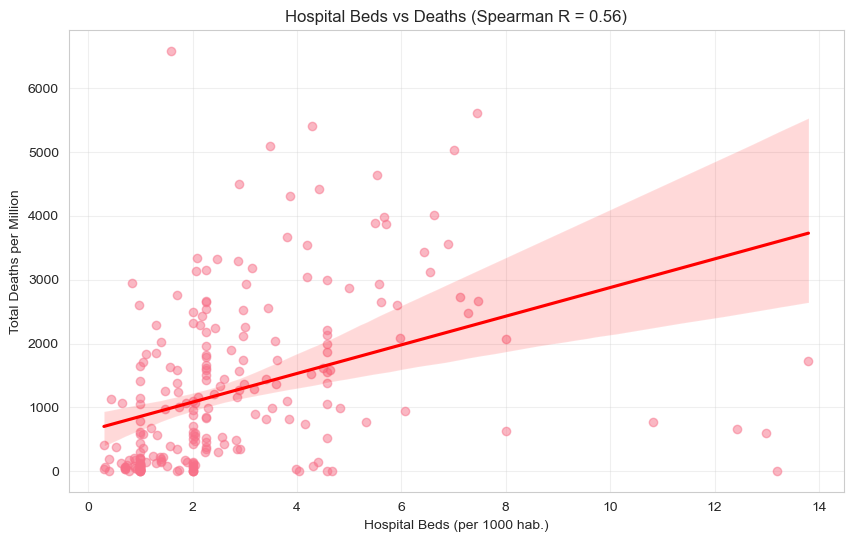

In [77]:
import scipy.stats as stats

r, p = stats.spearmanr(bivariate['hospital_beds_per_thousand'], 
                       bivariate['total_deaths_per_million'], nan_policy='omit')

# Gráfico
plt.figure(figsize=(10, 6))
sns.regplot(data=bivariate, x='hospital_beds_per_thousand', y='total_deaths_per_million', 
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

plt.title(f'Hospital Beds vs Deaths (Spearman R = {r:.2f})')
plt.xlabel('Hospital Beds (per 1000 hab.)')
plt.ylabel('Total Deaths per Million')
plt.grid(True, alpha=0.3)
plt.show()

As we can see, there is apparently a positive correlation between Hospital Beds and Deaths. Our intuition tells us: more beds = better sanitary system = less deaths. But the data is telling us: more beds = more deaths.

This could be happening because of:

1. Rich/Age Factor (as before): countries with a lot of hospital beds are richer countries with an old population.

2. Having hospital beds was not useful if you did not have ICUs or if the virus expanded in nursing homes.

3. The countries with robust sanitary systems tendo to have populations with more chronic diseases (diabetes, heart problems) that survive thanks to those beds in normal times, but they are more vulnerable to COVID.

In [78]:
res_beds = pg.partial_corr(data=bivariate.dropna(), 
                           x='hospital_beds_per_thousand', 
                           y='total_deaths_per_million', 
                           covar=['median_age'])

print(res_beds)

           n         r          CI95%     p-val
pearson  233  0.040373  [-0.09, 0.17]  0.540625


As we can see, at the moment we controll by age, the coefficient drops down drastically and it becomes non statistically significant. This tells us that the main factor of deaths is still the age of the population.

### Life Expectancy/Median Age vs. Deaths

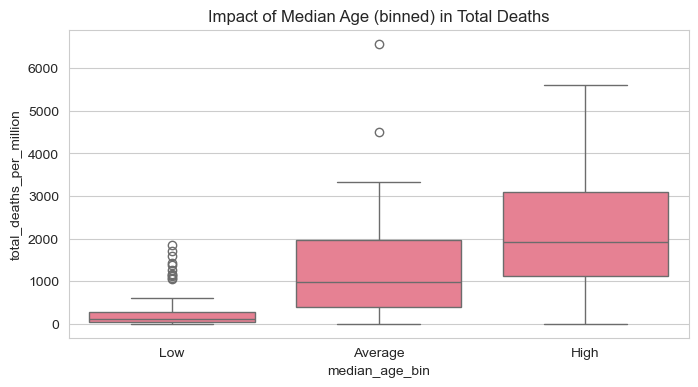

In [79]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='median_age_bin', y='total_deaths_per_million', data=bivariate)
plt.title('Impact of Median Age (binned) in Total Deaths')
plt.show()

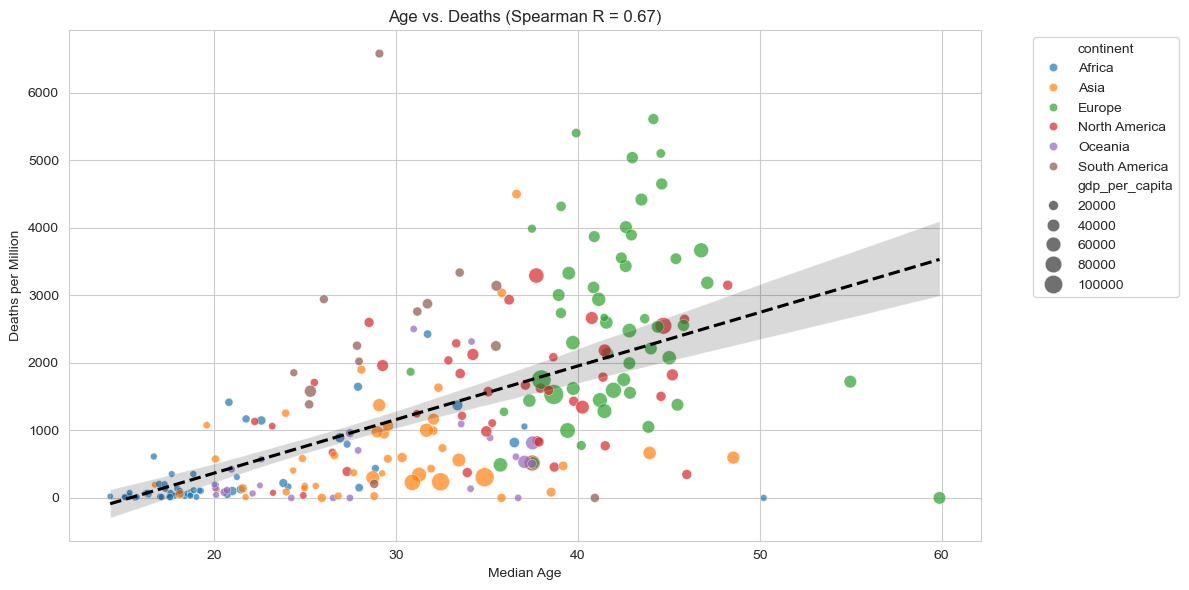

In [81]:
sns.scatterplot(data=bivariate, x='median_age', y='total_deaths_per_million', 
                hue='continent', size='gdp_per_capita', sizes=(20, 200), alpha=0.7, palette="tab10")

# Global tendency line
sns.regplot(data=bivariate, x='median_age', y='total_deaths_per_million', 
            scatter=False, color='black', line_kws={'linestyle':'--'})

# correlation
r, p = stats.spearmanr(bivariate['median_age'], bivariate['total_deaths_per_million'], nan_policy='omit')

plt.title(f'Age vs. Deaths (Spearman R = {r:.2f})')
plt.xlabel('Median Age')
plt.ylabel('Deaths per Million')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

As we can see, there is clearly a correlation between the median age of a country and the deaths per million with a strong positive Spearman correlation ($r \approx 0.67$).

One thing to highlight is the variation across continents.

- Europe is the one with more median age population and they are the continent with apparently more deaths per million. Nevertheless, there are countries in Europe that performed better than expected by the regression.

- Africa is obviously the best continent, but we have to take into account that the population there is the youngest one and that there can be a report bias.

- Asia was also a pretty good performer, with a moderate median age and with lower deaths per million than the average.

- Finally, we see that North America has some countries performing better and others worse and that South America has a lot of countries performing poorely, as their population is not as old as Europe and they had performed worse.

In [96]:
# 1. Simple Linear Regression Fit
df_reg = bivariate.dropna(subset=['median_age', 'total_deaths_per_million']).copy()

# y = mx + b
z = np.polyfit(df_reg['median_age'], df_reg['total_deaths_per_million'], 1)
p = np.poly1d(z)

# 2. Prediction and Residuals (excess performance)
df_reg['expected_deaths'] = p(df_reg['median_age'])
df_reg['excess_performance'] = df_reg['total_deaths_per_million'] - df_reg['expected_deaths']

# 3. ¿Outliers?
# Positive Big Value: Less people than expected died (good performance)
# Negative Big Value: More people than expected died (bad performance)

top_performers = df_reg.sort_values('excess_performance').head(5)
worst_performers = df_reg.sort_values('excess_performance', ascending=False).head(5)

print("--- Countries with better performance than expected ---")
print(top_performers[['country', 'median_age', 'total_deaths_per_million', 'excess_performance', 'gdp_per_capita']])

print("\n--- Countries with worse performance than expected ---")
print(worst_performers[['country', 'median_age', 'total_deaths_per_million', 'excess_performance', 'gdp_per_capita']])

--- Countries with better performance than expected ---
                       country  median_age  total_deaths_per_million  \
230                    Vatican   59.875000                   0.00000   
177               Saint Helena   50.214001                   0.00000   
181  Saint Pierre and Miquelon   45.988998                 347.22223   
104                      Japan   48.548000                 596.34753   
67            Falkland Islands   40.935001                   0.00000   

     excess_performance  gdp_per_capita  
230        -3529.162882    40223.011719  
177        -2762.771033     3435.171631  
181        -2080.386030    20718.388672  
104        -2034.262320    41837.910156  
67         -2026.682640    15093.464844  

--- Countries with worse performance than expected ---
             country  median_age  total_deaths_per_million  \
165             Peru   29.096001                 6575.6274   
155  North Macedonia   39.910000                 5399.8510   
31          Bulga

In this table we can see the top and worst performers. But, we also can see that the that the countries with better performance than expected are, on average (because there are exceptions), richer and smaller.

1. The Primary Predictor: Demographic Determinism

Our analysis confirms that median_age is the strongest single predictor of COVID-19 mortality (r≈0.67).

The Baseline: Age sets the biological "floor" for mortality. Older nations (Europe, North America) were structurally predisposed to higher death rates compared to younger nations (Africa), establishing a clear linear trend.

2. Residual Analysis: The "Unexplained" Variance

However, age does not explain the full picture. By analyzing the residuals (the difference between actual deaths and age-predicted deaths), we observed different patterns between top and worst performers:

* GDP Effect: Many high-income nations appear among the top performers, and low income ones in the worse performers. This may explain that richer countries could manage better the COVID in relation to the expected deaths explained by age.

* Population Scale: We observed that smaller countries were also top performers (some of them reported 0 deaths!). This is because of the isolation benefits they had in respect to other bigger countries with more people moving (easier for the virus to spread).

3. Roadmap: Towards a Multivariate Approach

Since median_age, gdp_per_capita, and population seem to interact with each other, a simple bivariate analysis is insufficient. To isolate the true impact of political management, we must move to a Multivariate Regression.

⚠️ Statistical Requirements for Causal Inference: For the upcoming multivariate analysis to be statistically valid (and not just exploratory), we must acknowledge that we will need to verify the following assumptions typical of OLS regression:

Normality of Residuals: Are the errors normally distributed? (We will need to check Q-Q plots).

Homoscedasticity: Is the variance of errors constant across all levels of GDP/Age?

No Multicollinearity: We must ensure that GDP and Age are not so correlated that they confuse the model.

Next Step: Build a multivariate model (Deaths∼Age+GDP+Population) to calculate the final "Performance Score."